# 01 — Exploratory Data Analysis (EDA)
## Telco Customer Churn

**Goal:** Understand the dataset structure before modeling.

Before building any model, we need to answer:
- How is the data distributed?
- How many customers churned?
- Which variables are most related to churn?
- Are there any null values or anomalies?

In [1]:
# Core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global visual settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

We load the original IBM Telco dataset.
`TotalCharges` comes as `object` type instead of numeric — we'll fix that in the next step.

In [2]:
# Load the dataset
DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={'gender': 'Gender', 'tenure': 'Tenure'})

# Define column groups
NUM_COLS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CAT_COLS = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows:    7,043
Columns: 21


,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Structure & Missing Values

Check data types and identify anomalies before any analysis.
`TotalCharges` is stored as `object` — it contains blank spaces that prevent numeric parsing.

In [8]:
# Data types and null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target only if it's still string
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(f'Churn dtype: {df["Churn"].dtype}')
print(f'Churn unique values: {df["Churn"].unique()}')
print('Data cleaning complete.')

Churn dtype: int64
Churn unique values: [0 1]
Data cleaning complete.


## 4. Target Variable: Churn Distribution

Understanding class balance is critical before choosing an evaluation metric.

If 74% of customers didn't churn, a model that always predicts "No Churn" 
would have 74% accuracy — but be completely useless.
That's why we use **AUC (Area Under the Curve)** as our primary metric.

AUC measures how well the model distinguishes between customers 
who will churn and those who won't.

| AUC | Interpretation |
|-----|----------------|
| 1.0 | Perfect model |
| 0.9+ | Excellent |
| 0.8+ | Good |
| 0.7+ | Acceptable |
| 0.5 | Random guessing |

Churn Distribution:
  No Churn (0): 5,174  (73.5%)
  Churn    (1): 1,869  (26.5%)


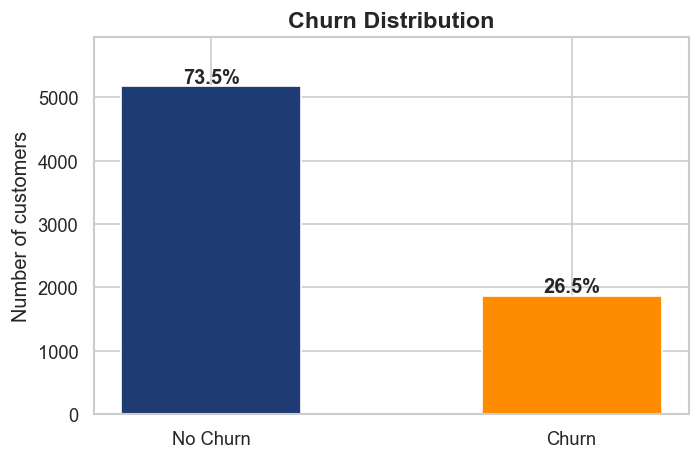

In [9]:
churn_counts = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

print('Churn Distribution:')
print(f'  No Churn (0): {churn_counts.iloc[0]:,}  ({churn_pct.iloc[0]:.1f}%)')
print(f'  Churn    (1): {churn_counts.iloc[1]:,}  ({churn_pct.iloc[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Churn', 'Churn'], churn_counts.values,
              color=['#1f3b73', '#FF8C00'], edgecolor='white', width=0.5)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=12, weight='bold')
ax.set_title('Churn Distribution', fontsize=14, weight='bold')
ax.set_ylabel('Number of customers')
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', dpi=150)
plt.show()

## 5. Skewness & Outlier Detection

Before analyzing distributions by churn status, we check the shape of each 
numerical variable using boxplots.

Skewness indicates how asymmetric the distribution is:
- **> 0.5** → right-skewed (tail on the right)
- **< -0.5** → left-skewed (tail on the left)
- **Between -0.5 and 0.5** → approximately normal

High skewness may require log transformation before modeling.

C:\Users\danip\AppData\Local\Temp\ipykernel_30328\2886278582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_0, data_1], labels=['No Churn', 'Churn'],
C:\Users\danip\AppData\Local\Temp\ipykernel_30328\2886278582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_0, data_1], labels=['No Churn', 'Churn'],
C:\Users\danip\AppData\Local\Temp\ipykernel_30328\2886278582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_0, data_1], labels=['No Churn', 'Churn'],


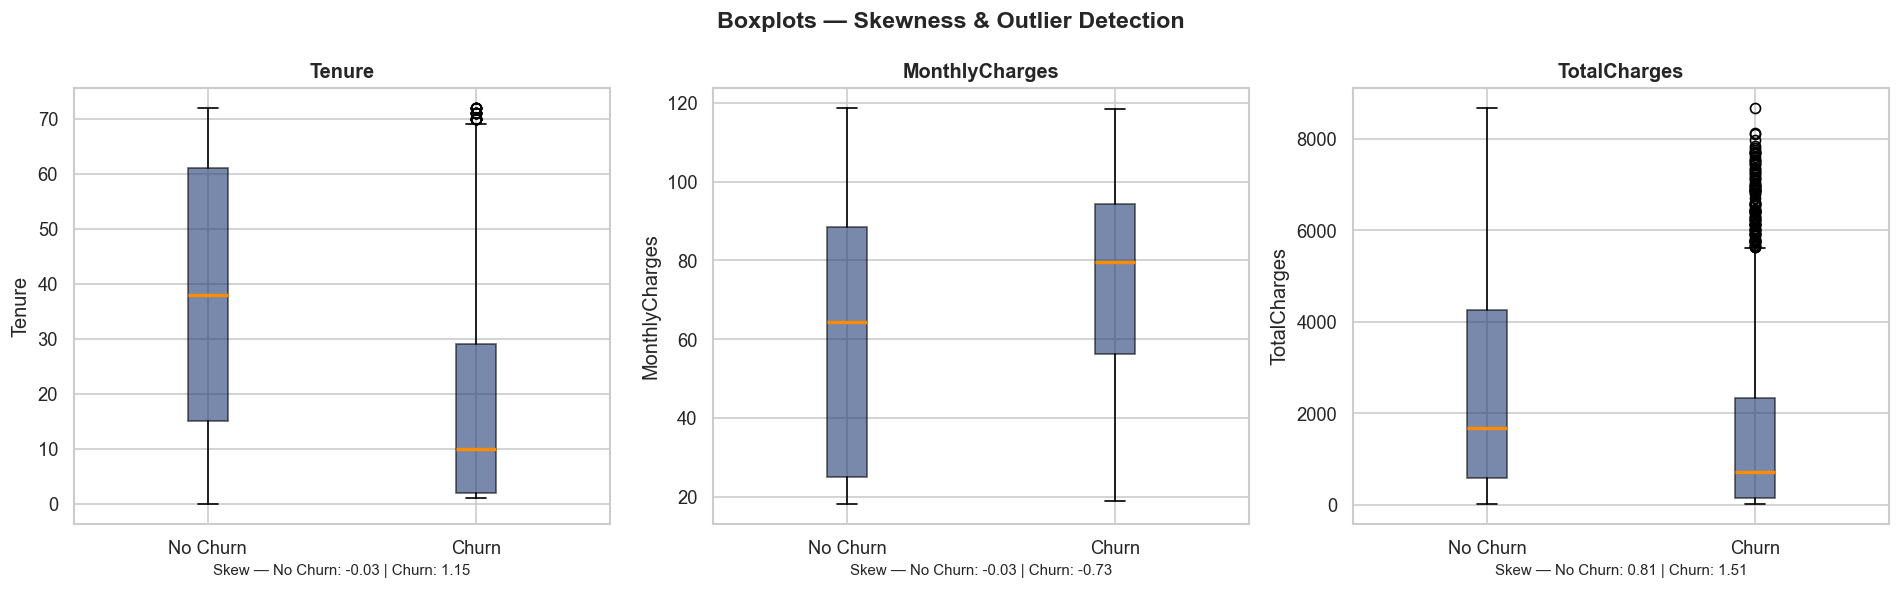

Skewness Summary:
  Tenure: 0.240  →  approximately normal
  MonthlyCharges: -0.221  →  approximately normal
  TotalCharges: 0.964  →  right-skewed


In [11]:
NUM_COLS = ['Tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots — Skewness & Outlier Detection', fontsize=14, weight='bold')
for ax, col in zip(axes, NUM_COLS):
    data_0 = df[df['Churn'] == 0][col]
    data_1 = df[df['Churn'] == 1][col]
    ax.boxplot([data_0, data_1], labels=['No Churn', 'Churn'],
               patch_artist=True,
               boxprops=dict(facecolor='#1f3b73', alpha=0.6),
               medianprops=dict(color='#FF8C00', linewidth=2))
    ax.set_title(col, weight='bold')
    ax.set_ylabel(col)
    skew_0 = data_0.skew()
    skew_1 = data_1.skew()
    ax.set_xlabel(f'Skew — No Churn: {skew_0:.2f} | Churn: {skew_1:.2f}', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/02_boxplots_skewness.png', dpi=150)
plt.show()
print('Skewness Summary:')
for col in NUM_COLS:
    skew = df[col].skew()
    print(f'  {col}: {skew:.3f}  →  {"right-skewed" if skew > 0.5 else "left-skewed" if skew < -0.5 else "approximately normal"}')

## 5.2 Distribution Shape — Mean vs Median (KDE)

A KDE (Kernel Density Estimate) plots the shape of each distribution.
The gap between **mean** and **median** reveals skewness direction:
- Mean > Median → Positive skew (right tail)
- Mean < Median → Negative skew (left tail)
- Mean ≈ Median → Symmetrical

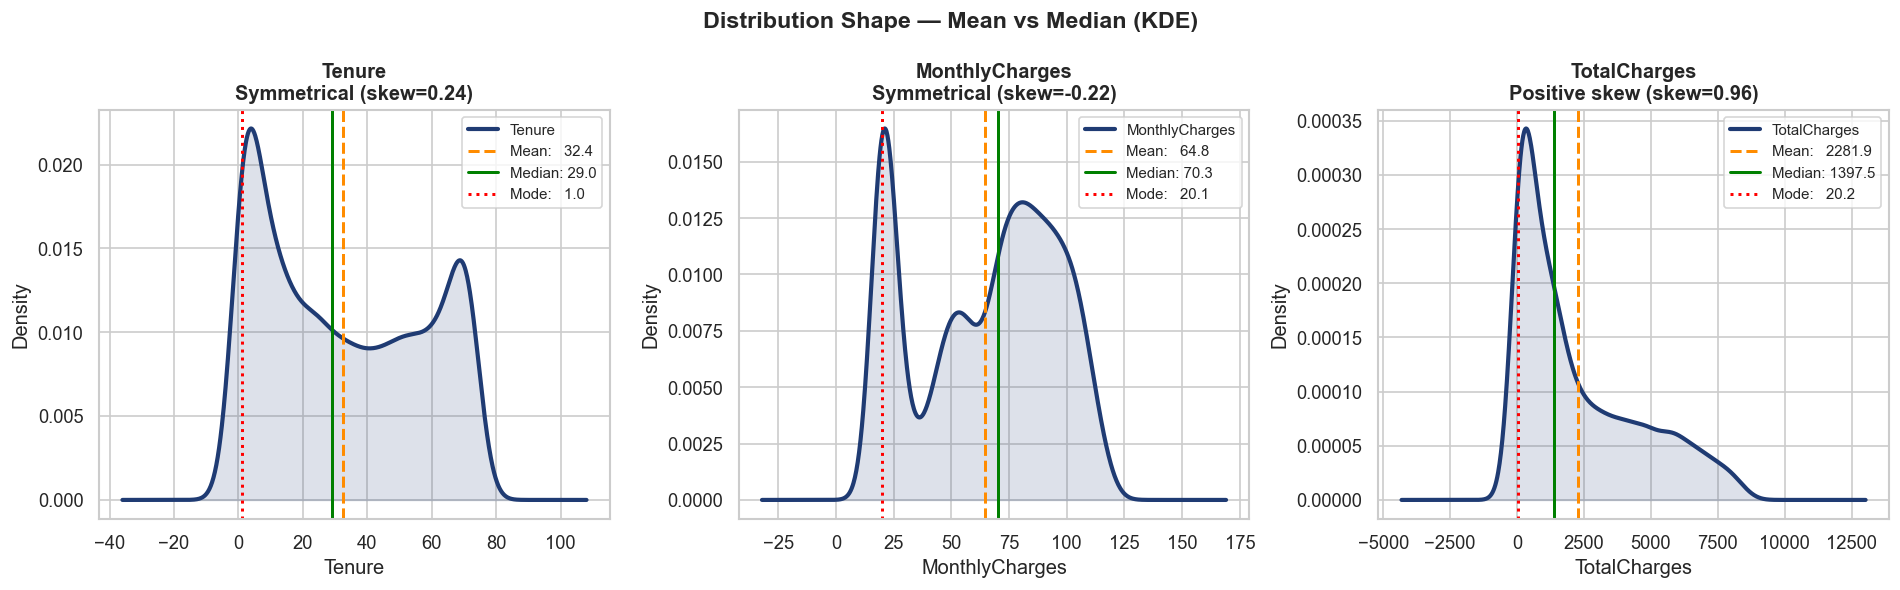

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution Shape — Mean vs Median (KDE)', fontsize=14, weight='bold')

for ax, col in zip(axes, NUM_COLS):
    data = df[col]
    mean_val   = data.mean()
    median_val = data.median()
    mode_val   = data.mode()[0]

    # KDE plot
    data.plot.kde(ax=ax, color='#1f3b73', linewidth=2.5)
    ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(),
                    alpha=0.15, color='#1f3b73')

    # Reference lines
    ax.axvline(mean_val,   color='#FF8C00', linestyle='--', linewidth=1.8, label=f'Mean:   {mean_val:.1f}')
    ax.axvline(median_val, color='green',   linestyle='-',  linewidth=1.8, label=f'Median: {median_val:.1f}')
    ax.axvline(mode_val,   color='red',     linestyle=':',  linewidth=1.8, label=f'Mode:   {mode_val:.1f}')

    skew = data.skew()
    direction = 'Positive skew' if skew > 0.5 else 'Negative skew' if skew < -0.5 else 'Symmetrical'
    ax.set_title(f'{col}\n{direction} (skew={skew:.2f})', weight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel(col)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_kde_skewness.png', dpi=150)
plt.show()

## 5.3 KDE by Churn Status

Same KDE plot split by churn status to reveal distributional differences.

**How to read Density (Y axis):**
The Y axis shows probability density — not raw counts.
A higher peak means more customers are concentrated at that value.
The total area under each curve always equals 1.0, which allows fair 
comparison between groups of different sizes (No Churn = 5,174 vs Churn = 1,869).

**Key insight on Tenure:**
- Churn customers peak at months 0–10 → they leave early
- No Churn customers are more evenly spread, with a second peak at 60–70 months
- Mean Churn ~18 months vs No Churn ~38 months
- Tenure is likely the strongest single predictor in this dataset

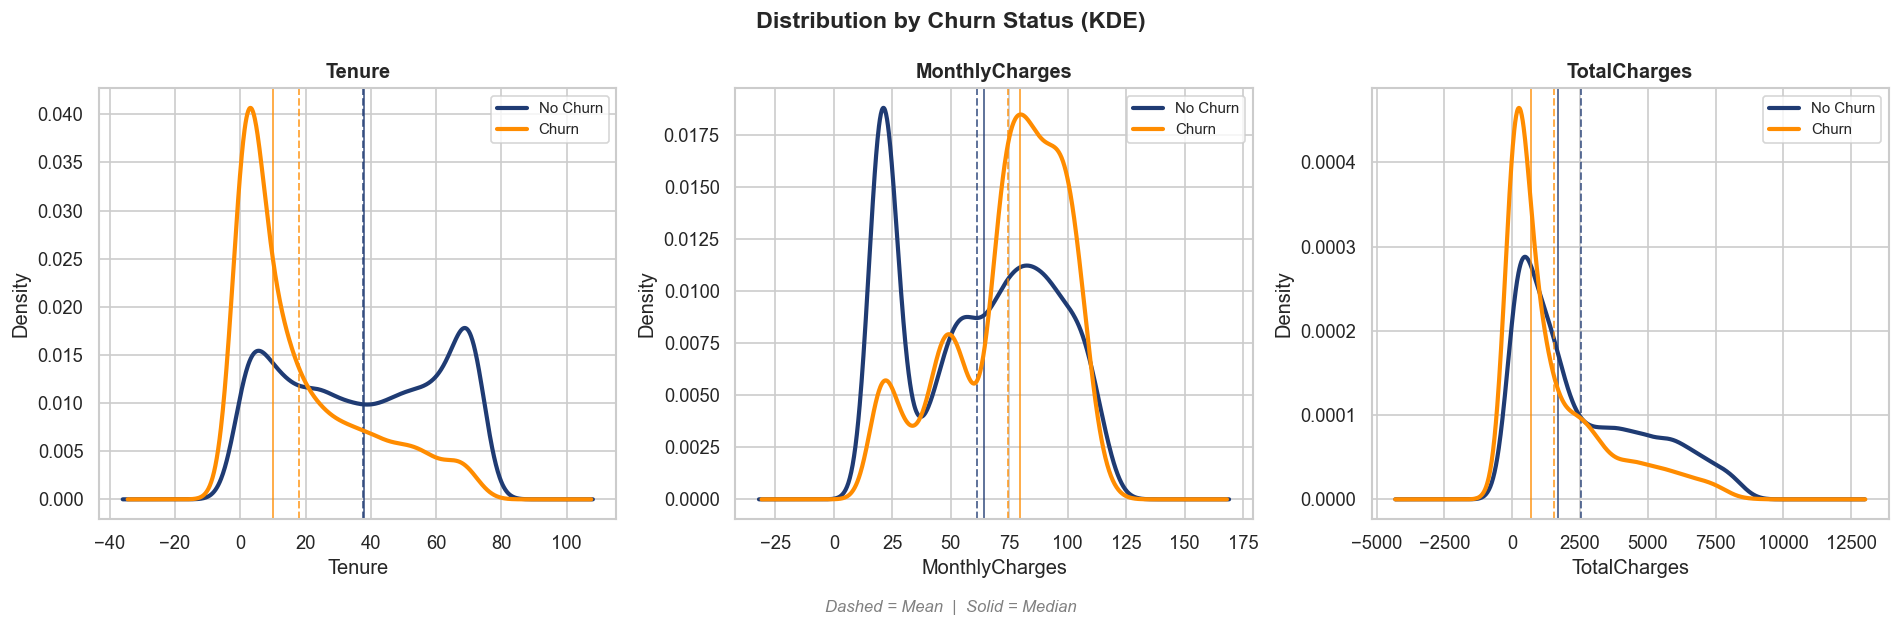

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution by Churn Status (KDE)', fontsize=14, weight='bold')

for ax, col in zip(axes, NUM_COLS):
    for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
        data = df[df['Churn'] == label][col]
        mean_val   = data.mean()
        median_val = data.median()

        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
        ax.axvline(mean_val,   color=color, linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(median_val, color=color, linestyle='-',  linewidth=1.2, alpha=0.7)

    ax.set_title(col, weight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel(col)
    ax.legend(fontsize=9)

# Add annotation explaining lines
fig.text(0.5, -0.02, 'Dashed = Mean  |  Solid = Median',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig('../outputs/04_kde_by_churn.png', dpi=150)
plt.show()

## 6. Categorical Variables — Churn Rate by Segment

For each categorical variable, we calculate what percentage of customers 
in that group churned.

This tells us which variables have the most predictive power.
Higher spread between groups = stronger signal for the model.

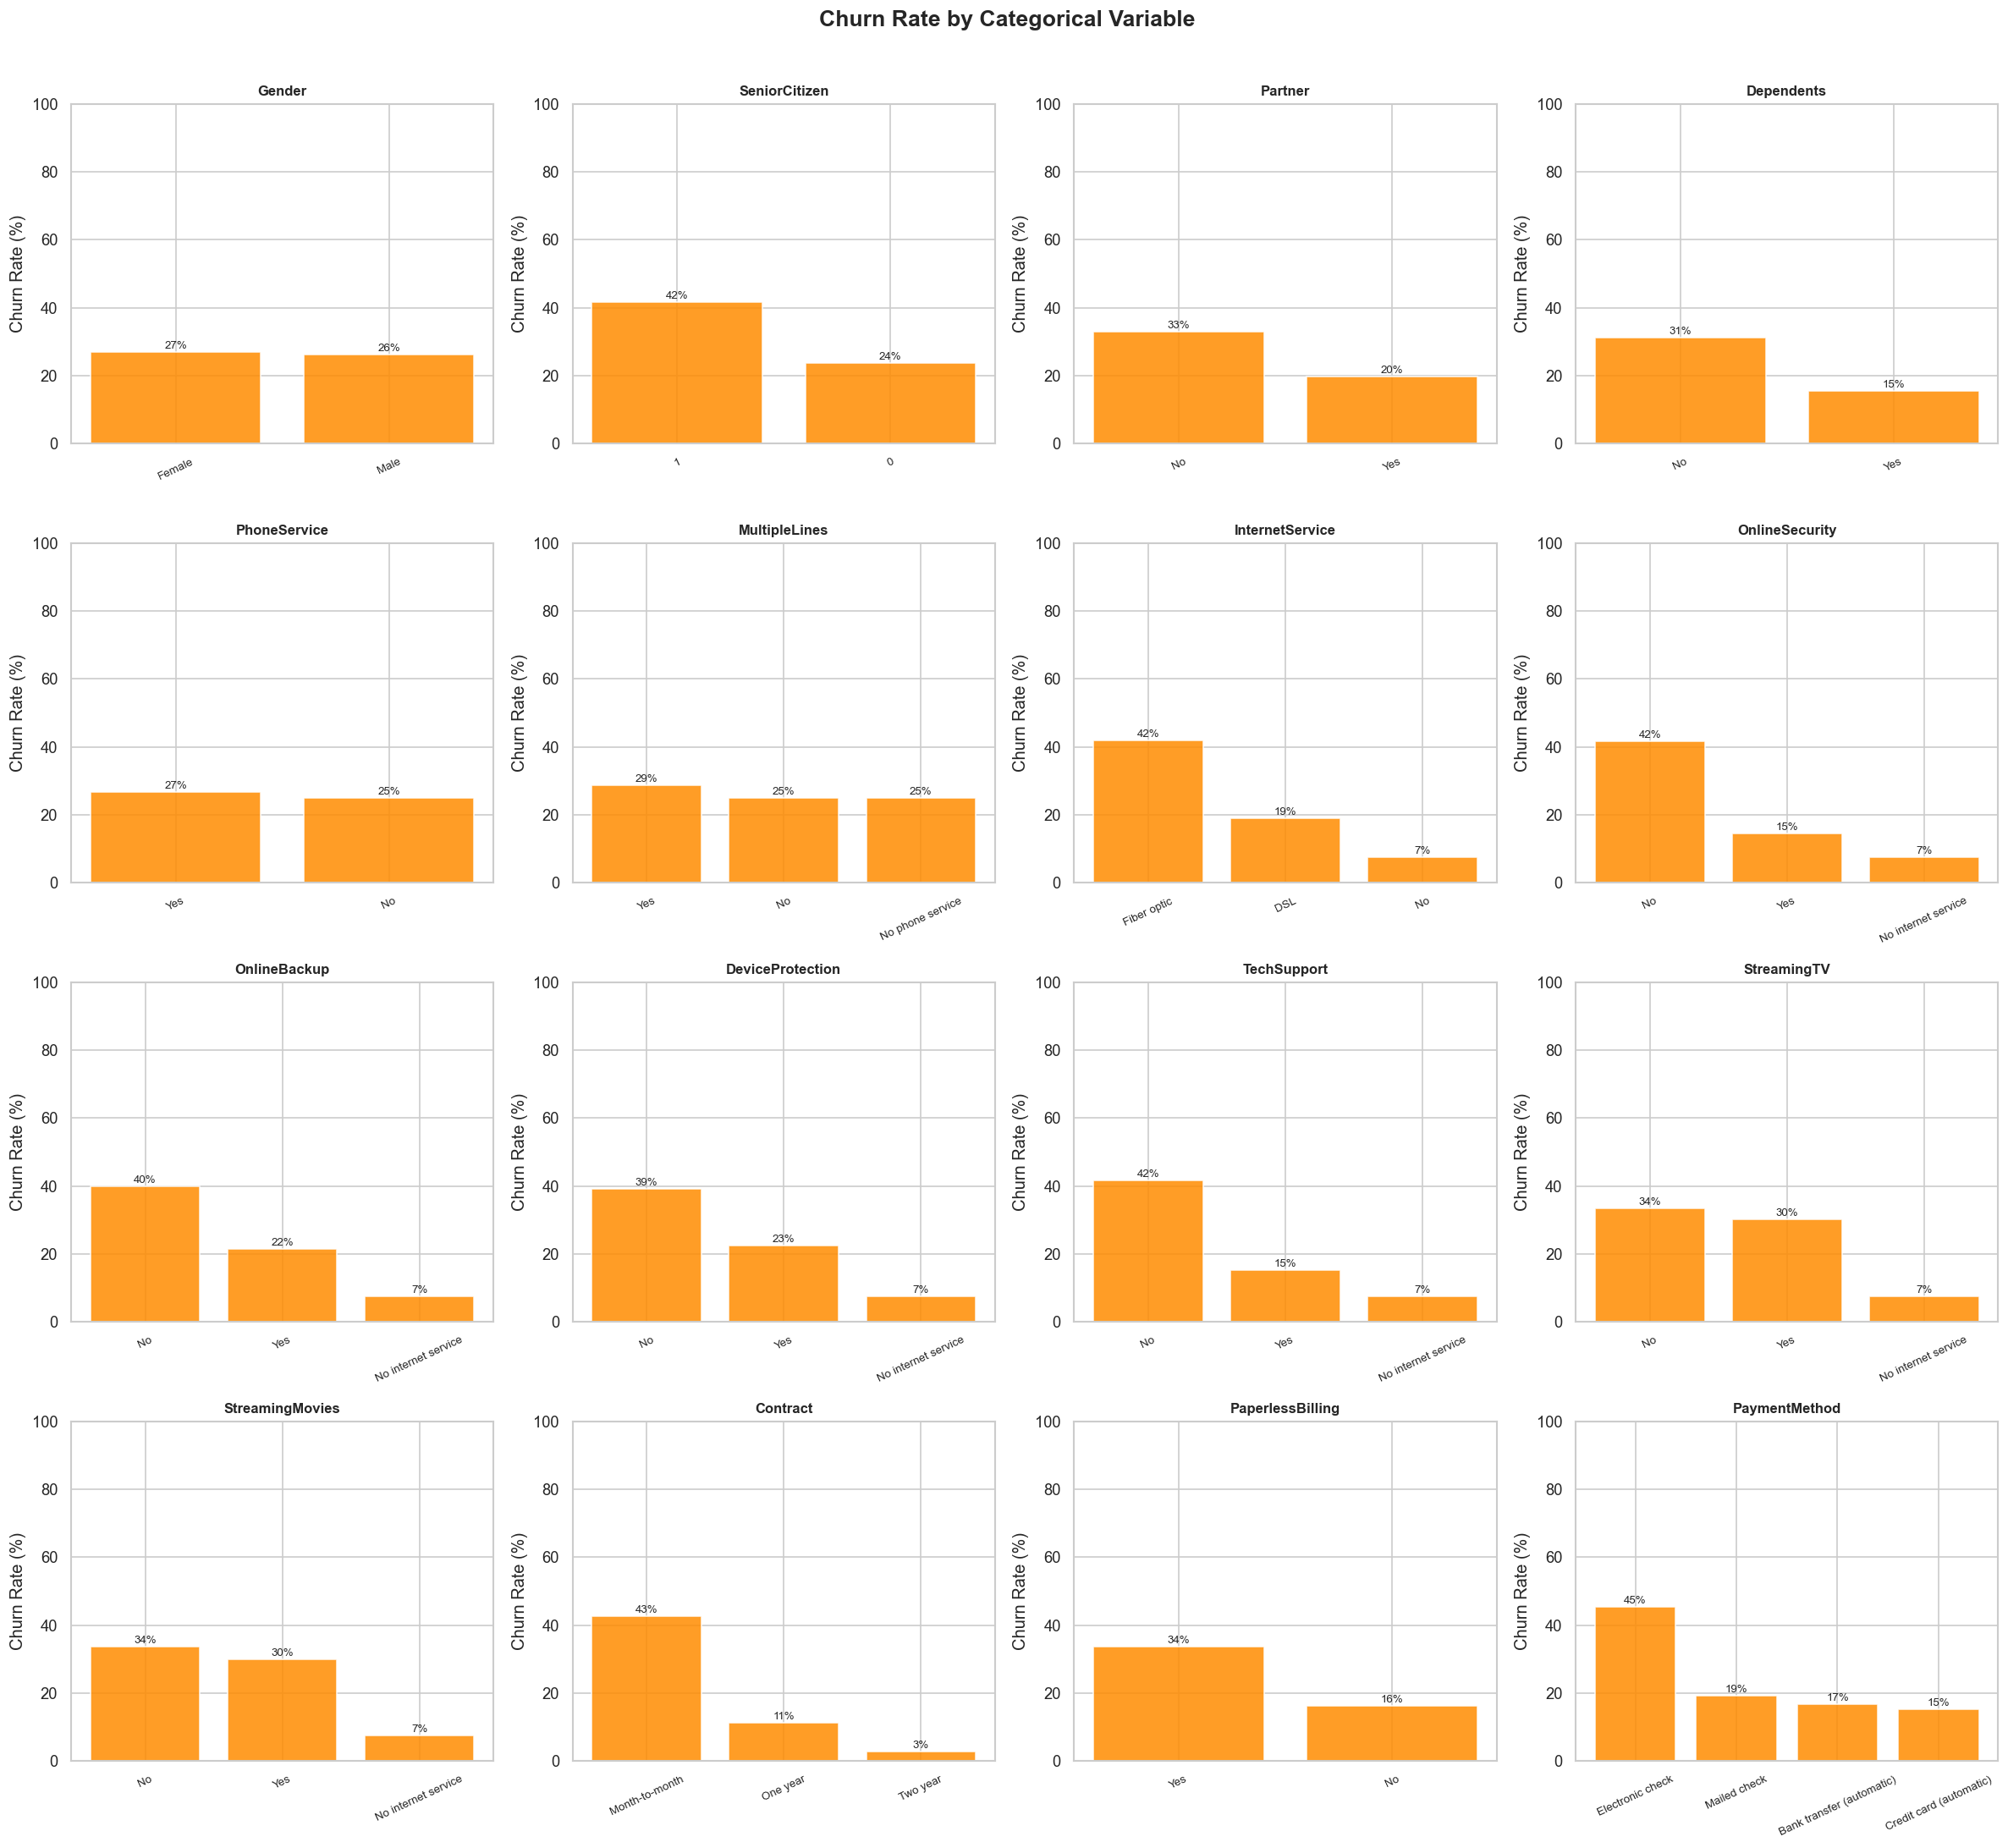

In [15]:
CAT_COLS = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
fig.suptitle('Churn Rate by Categorical Variable', fontsize=16, weight='bold', y=1.01)
axes = axes.flatten()

for ax, col in zip(axes, CAT_COLS):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values * 100,
                  color='#FF8C00', edgecolor='white', alpha=0.85)
    ax.set_title(col, weight='bold', fontsize=10)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val*100:.0f}%', ha='center', fontsize=8)

# Hide unused subplots
for i in range(len(CAT_COLS), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/05_churn_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predictive Power Ranking

We measure the spread between the highest and lowest churn rate 
within each categorical variable.

**Larger spread = stronger signal for the model.**
This helps prioritize which variables matter most.

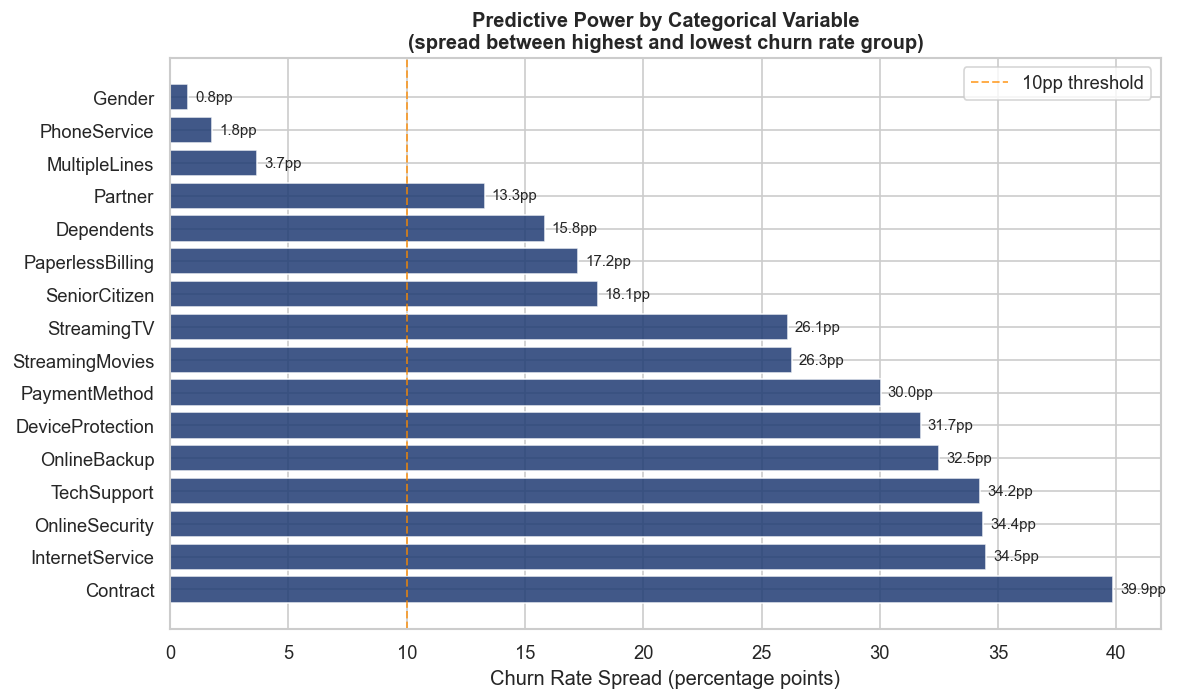

Top 5 most discriminative variables:
       variable    spread max_churn_group  max_churn_rate
       Contract 39.877819  Month-to-month       42.709677
InternetService 34.487785     Fiber optic       41.892765
 OnlineSecurity 34.361744              No       41.766724
    TechSupport 34.230493              No       41.635474
   OnlineBackup 32.523776              No       39.928756


In [16]:
predictive_power = []
for col in CAT_COLS:
    rates = df.groupby(col)['Churn'].mean()
    spread = rates.max() - rates.min()
    predictive_power.append({
        'variable':        col,
        'spread':          spread * 100,
        'max_churn_rate':  rates.max() * 100,
        'max_churn_group': rates.idxmax()
    })

pp_df = pd.DataFrame(predictive_power).sort_values('spread', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(pp_df['variable'], pp_df['spread'],
               color='#1f3b73', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, pp_df['spread']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}pp', va='center', fontsize=9)
ax.set_title('Predictive Power by Categorical Variable\n(spread between highest and lowest churn rate group)',
             weight='bold')
ax.set_xlabel('Churn Rate Spread (percentage points)')
ax.axvline(10, color='#FF8C00', linestyle='--', linewidth=1.2, alpha=0.7, label='10pp threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06_predictive_power.png', dpi=150)
plt.show()

print('Top 5 most discriminative variables:')
print(pp_df[['variable', 'spread', 'max_churn_group', 'max_churn_rate']].head().to_string(index=False))

## 8. Correlation Matrix

Correlation measures the linear relationship between numerical variables.
Values range from -1 to 1:
- **1.0** → perfect positive correlation
- **0.0** → no linear relationship
- **-1.0** → perfect negative correlation

We include `Churn` as numeric (0/1) to see which variables 
correlate directly with the target.

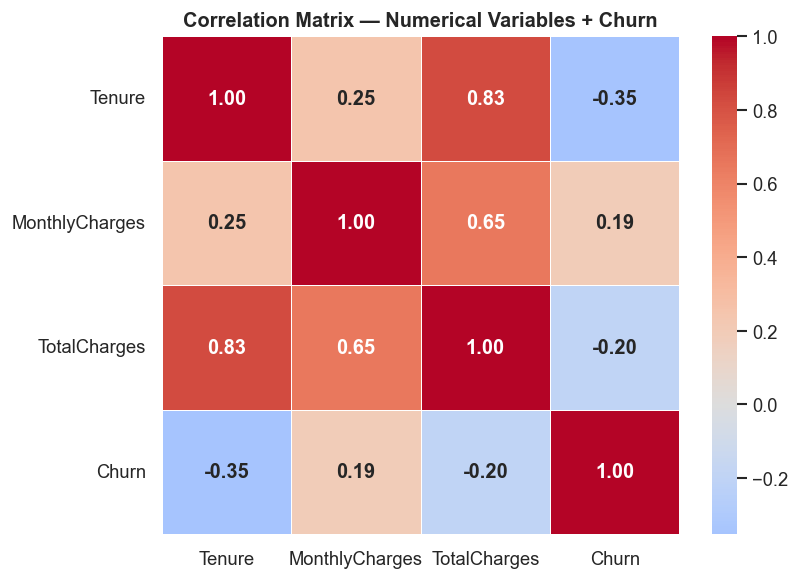

Correlation with Churn:
MonthlyCharges    0.193356
TotalCharges     -0.199037
Tenure           -0.352229
Name: Churn, dtype: float64


In [17]:
corr_cols = NUM_COLS + ['Churn']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Correlation Matrix — Numerical Variables + Churn', weight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_matrix.png', dpi=150)
plt.show()

print('Correlation with Churn:')
print(corr_matrix['Churn'].drop('Churn').sort_values(ascending=False))

## 9. EDA Summary

Key findings before moving to Feature Engineering and Modeling.

In [18]:
print('=' * 60)
print('EDA SUMMARY — TELCO CUSTOMER CHURN')
print('=' * 60)

print(f'\nDataset:')
print(f'  Total customers:      {len(df):,}')
print(f'  Global churn rate:    {df["Churn"].mean()*100:.1f}%')
print(f'  Numerical variables:  {len(NUM_COLS)}')
print(f'  Categorical variables:{len(CAT_COLS)}')

print(f'\nClass Balance:')
print(f'  No Churn: {(df["Churn"]==0).sum():,} ({(df["Churn"]==0).mean()*100:.1f}%)')
print(f'  Churn:    {(df["Churn"]==1).sum():,} ({(df["Churn"]==1).mean()*100:.1f}%)')
print(f'  → Imbalanced dataset: use AUC, not accuracy')

print(f'\nNumerical Variables — Key Findings:')
print(f'  Tenure:         strongest predictor (corr=-0.35)')
print(f'                  Churn avg={df[df["Churn"]==1]["Tenure"].mean():.0f} months vs No Churn avg={df[df["Churn"]==0]["Tenure"].mean():.0f} months')
print(f'  MonthlyCharges: Churn avg=${df[df["Churn"]==1]["MonthlyCharges"].mean():.1f} vs No Churn avg=${df[df["Churn"]==0]["MonthlyCharges"].mean():.1f}')
print(f'  TotalCharges:   high multicollinearity with Tenure (0.83) → needs derived features')

print(f'\nCategorical Variables — Top 5 by Predictive Power:')
predictive_power = []
for col in CAT_COLS:
    rates = df.groupby(col)['Churn'].mean()
    spread = rates.max() - rates.min()
    predictive_power.append({'variable': col, 'spread': spread * 100,
                              'max_churn_group': rates.idxmax(),
                              'max_churn_rate': rates.max() * 100})
pp_df = pd.DataFrame(predictive_power).sort_values('spread', ascending=False)
for _, row in pp_df.head().iterrows():
    print(f'  {row["variable"]:<20} spread={row["spread"]:.1f}pp  highest risk: {row["max_churn_group"]} ({row["max_churn_rate"]:.0f}%)')

print(f'\nHigh Risk Customer Profile:')
print(f'  → Month-to-month contract')
print(f'  → Fiber optic internet')
print(f'  → No OnlineSecurity or TechSupport')
print(f'  → Electronic check payment')
print(f'  → Low tenure (< 12 months)')

print(f'\nNext Step → 02_feature_engineering.ipynb')
print('=' * 60)

EDA SUMMARY — TELCO CUSTOMER CHURN

Dataset:
  Total customers:      7,043
  Global churn rate:    26.5%
  Numerical variables:  3
  Categorical variables:16

Class Balance:
  No Churn: 5,174 (73.5%)
  Churn:    1,869 (26.5%)
  → Imbalanced dataset: use AUC, not accuracy

Numerical Variables — Key Findings:
  Tenure:         strongest predictor (corr=-0.35)
                  Churn avg=18 months vs No Churn avg=38 months
  MonthlyCharges: Churn avg=$74.4 vs No Churn avg=$61.3
  TotalCharges:   high multicollinearity with Tenure (0.83) → needs derived features

Categorical Variables — Top 5 by Predictive Power:
  Contract             spread=39.9pp  highest risk: Month-to-month (43%)
  InternetService      spread=34.5pp  highest risk: Fiber optic (42%)
  OnlineSecurity       spread=34.4pp  highest risk: No (42%)
  TechSupport          spread=34.2pp  highest risk: No (42%)
  OnlineBackup         spread=32.5pp  highest risk: No (40%)

High Risk Customer Profile:
  → Month-to-month contract
